In [20]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [23]:
opt = Optimizer()
opt.independent_properties_calc()
print(opt.mission_profile.duration)
opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
opt.design_variables_initial_guess = {
    "arm_diameter": 40.0,
    "arm_thickness": 0.8,
    "strut_diameter": 40.0,
    "strut_thickness": 0.8,
    "strut_distance": 475,
    "hub_radius": 275,
    "hub_flange_thickness": 0.8,
    "hub_web_thickness": 0.8
}

res = opt.run_opt()

x = np.array(res.x)
x_expanded = list(opt.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt.test_results(x)


dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"objective: {res.fun}")


print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640
Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30901200265000806
   strut_diameter: 9.0
   strut_thickness: 0.254
   strut_distance: 252.91253336410463
   hub_radius: 252.9044126362785
   hub_flange_thickness: 0.7000000000000001
   hub_web_thickness: 0.7000000000000002
constraints
   deflection: 0.9999999999973983
   stress: 0.9389540971198743
   displacement amplitude: 0.926283518061096
   energy: 0.8715288755032764
   damage: 0.0
objective: 0.4916766651673725
OPT_OUTPUT
Initial guess opt actual:
[ 50.           0.309012     9.           0.254      252.91253336
 252.90441264   0.7          0.7       ]


In [3]:
import os
import pandas as pd

table_path = "Tables/Sensitivity_Testing_Ver_2.csv"

for i in range(8):
    case_title = "Case " + str(i)
    x2 = [
        ((x[0] - 0.001 * x[0])) if i in (0, 1, 2, 3) else (x[0] + 0.001 * x[0]),
        ((x[1] - 0.001 * x[1])) if i in (0, 1, 4, 5) else (x[1] + 0.001 * x[1]),
        ((x[2] - 0.001 * x[2])) if i in (0, 3, 5, 7) else (x[2] + 0.001 * x[2])
    ]
    print(x2)
    cons_res_opt, cons_labels_opt = opt.test_results(x2)
    mass = opt.mass(opt.reform_dvs(x2))

    data = {}
    data.update(opt.reform_dvs(x2))
    opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
    data.update(opt_dictionary)
    data.update({"mass": mass * 1000})

    print(data)

    # Ensure directory exists
    os.makedirs(os.path.dirname(table_path), exist_ok=True)

    new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

    if os.path.exists(table_path):
        try:
            df_existing = pd.read_csv(table_path, index_col=0)
        except Exception:
            df_existing = pd.DataFrame()

        if df_existing.empty:
            df = new_col_df
        else:
            for idx in new_col_df.index:
                if idx not in df_existing.index:
                    df_existing.loc[idx] = pd.NA
            df_existing[case_title] = new_col_df[case_title]
            df = df_existing
    else:
        df = new_col_df

    df.to_csv(table_path, index=True)


[np.float64(0.3019488863722513), np.float64(0.36053487938214956), np.float64(556.2306003338063)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.3019488863722513), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36053487938214956), 'strut_distance': np.float64(556.2306003338063), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.001238748777397), 'stress': np.float64(0.9790032595698512), 'displacement amplitude': np.float64(0.6880215188266572), 'energy': np.float64(0.32588950602437217), 'damage': np.float64(0.0), 'mass': np.float64(0.8240765473051699)}
[np.float64(0.3019488863722513), np.float64(0.36053487938214956), np.float64(557.3441751092494)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.3019488863722513), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36053487938214956), 'strut_distance': np.float64(557.3441751092494), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'defl

In [4]:
import os
import pandas as pd
table_path = "Tables/Sensitivity_Testing_Ver_2.csv"
case_title = "Optimal Point"

mass = opt.mass(opt.reform_dvs(x))

data = {}
data.update(opt.reform_dvs(x))
opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
data.update(opt_dictionary)
data.update({"mass":mass * 1000})

print(data)

# Ensure directory exists
os.makedirs(os.path.dirname(table_path), exist_ok=True)

new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

if os.path.exists(table_path):
    try:
        df_existing = pd.read_csv(table_path, index_col=0)
    except Exception:
        df_existing = pd.DataFrame()

    if df_existing.empty:
        df = new_col_df
    else:
        for idx in new_col_df.index:
            if idx not in df_existing.index:
                df_existing.loc[idx] = pd.NA
        df_existing[case_title] = new_col_df[case_title]
        df = df_existing
else:
    df = new_col_df

df.to_csv(table_path, index=True) 


{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30225113750976107), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36089577515730686), 'strut_distance': np.float64(556.7873877215278), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(0.9993820893945647), 'stress': np.float64(0.9770362886003495), 'displacement amplitude': np.float64(0.6797064373372121), 'energy': np.float64(0.32589463889464126), 'damage': np.float64(0.0), 'mass': np.float64(0.8250114545173702)}


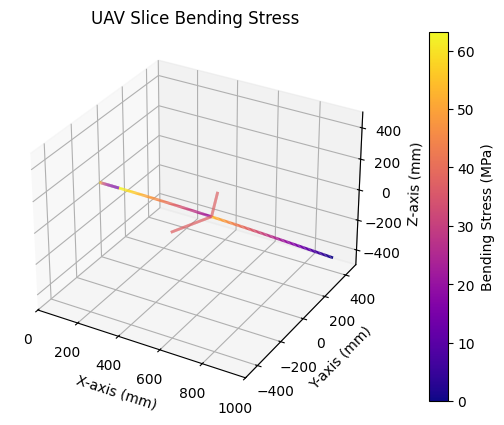

In [5]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

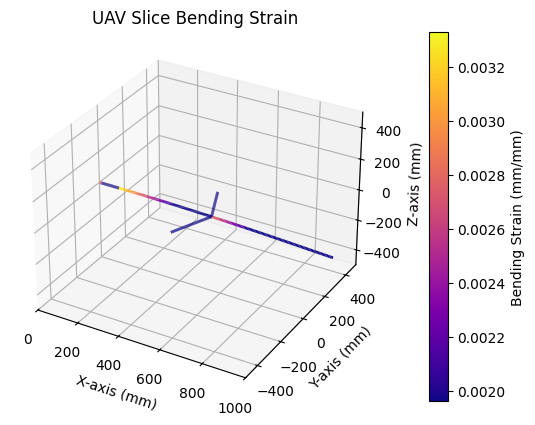

In [6]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

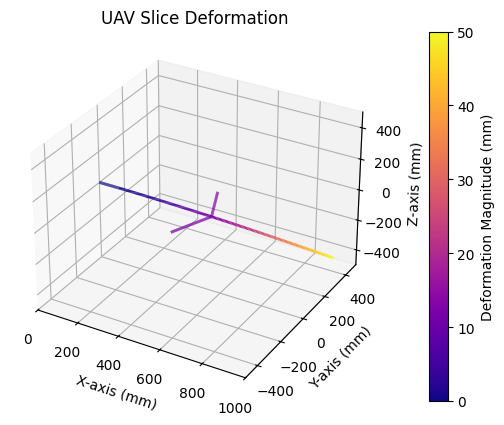

In [7]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [8]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 24.247720460214193 Hz
Second Nf: 55.42780364276522 Hz


In [9]:
print(352.7148774623214 * uc.rad_per_s_to_Hz)

print(max(opt.fea.beam_system.mag_displacements_amplitude))

56.1363162501806
52.27863351822437


In [4]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 50, design_variables, (400, 600), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

KeyboardInterrupt: 

{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.5), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': 556.7873877215278, 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


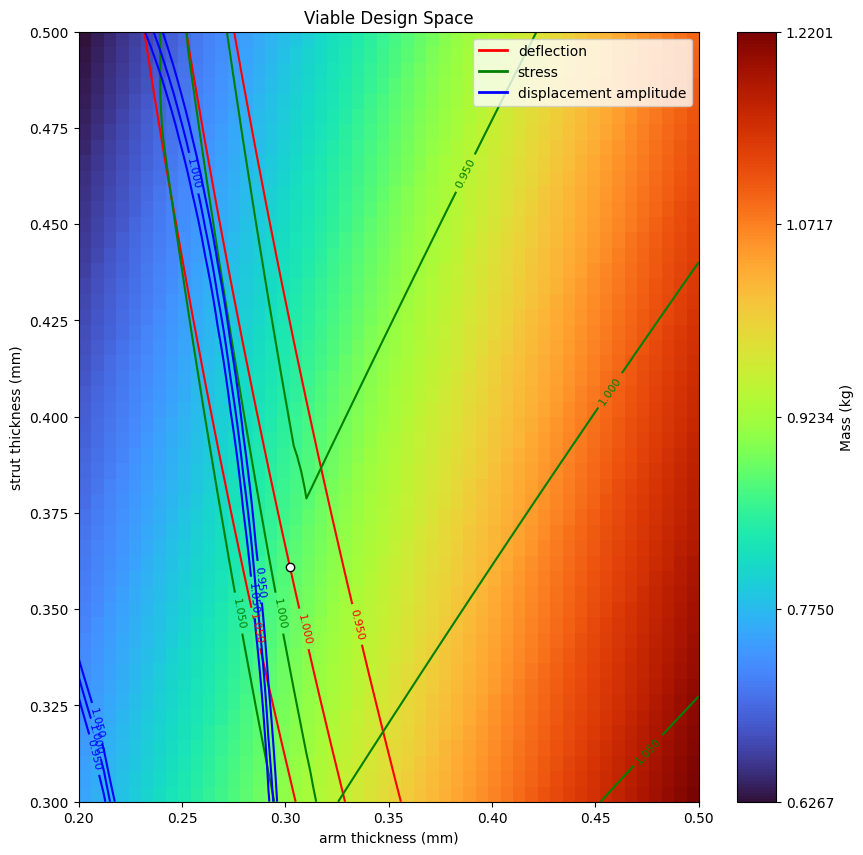

In [11]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 50, design_variables, (0.2, 0.5), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': 0.30225113750976107, 'strut_diameter': 50.0, 'strut_thickness': np.float64(3.175), 'strut_distance': np.float64(1127.3), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


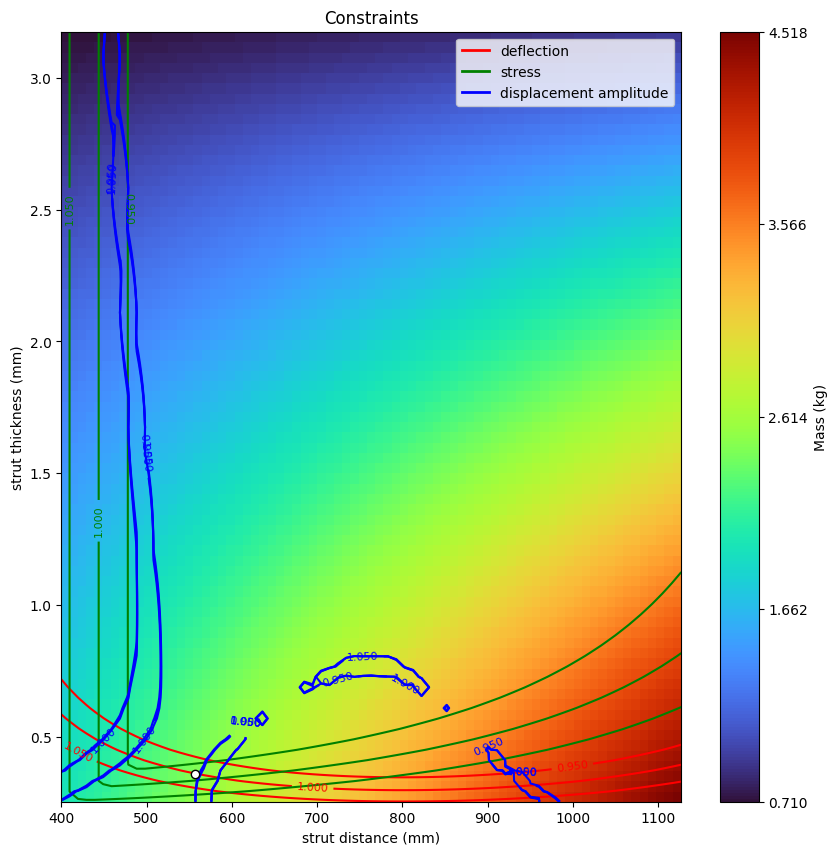

In [12]:
# zoomed out
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 75, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

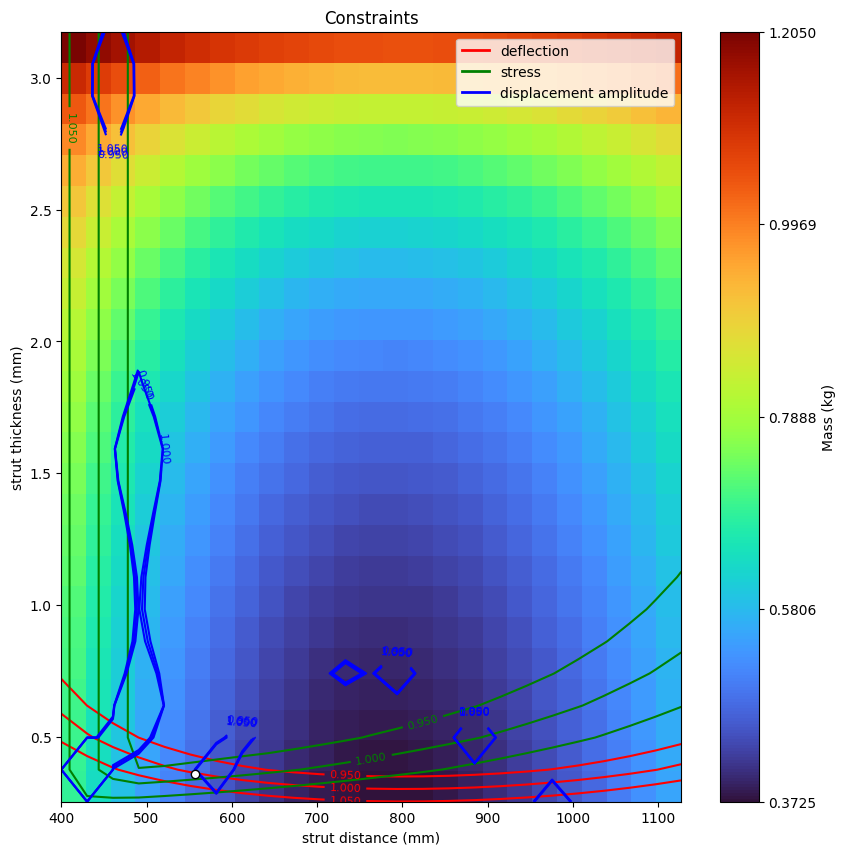

In [13]:
# TEST
from Scripts.visualization import design_space_test_cons
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_test_cons(opt, "strut_distance", "strut_thickness", 25, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

In [24]:
design_variables = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": 1.75,
    "strut_distance": 1100,
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}
constraints_res, labels = opt.constraint_calculations(design_variables, active_constraints, True)
for i in range(len(constraints_res)):
    print(f"{labels[i]}: {constraints_res[i]}")

deflection: 0.9915091224734127
stress: 0.933274920960595
displacement amplitude: 0.7527856736236678


In [25]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

KeyboardInterrupt: 

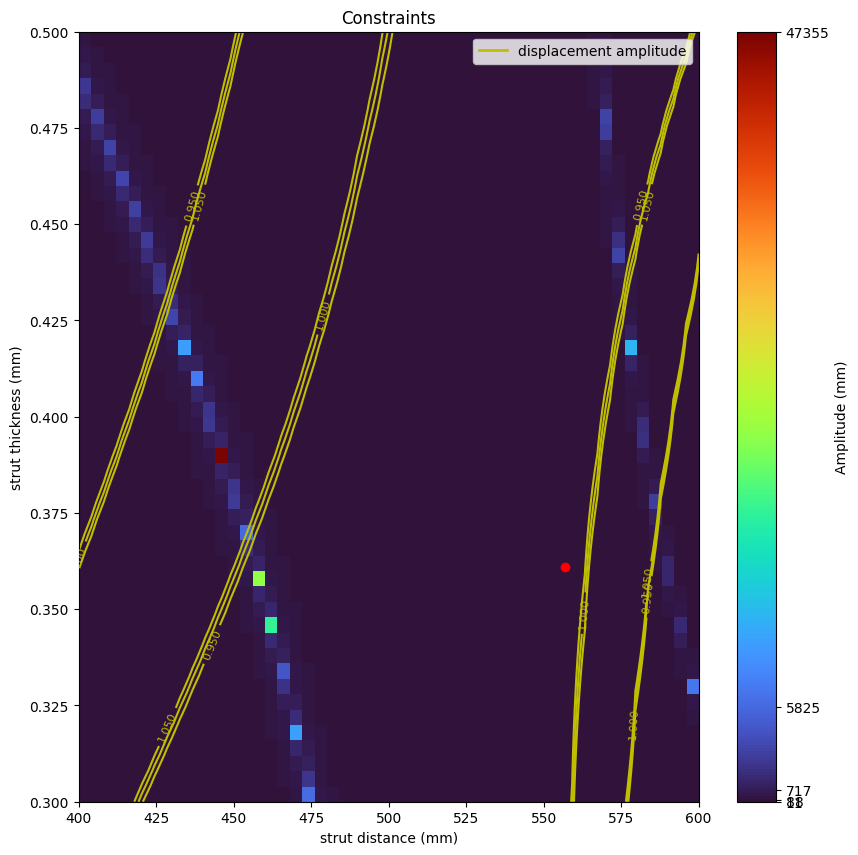

In [16]:
# plot the space
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(400,600),(0.3,0.5),{
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

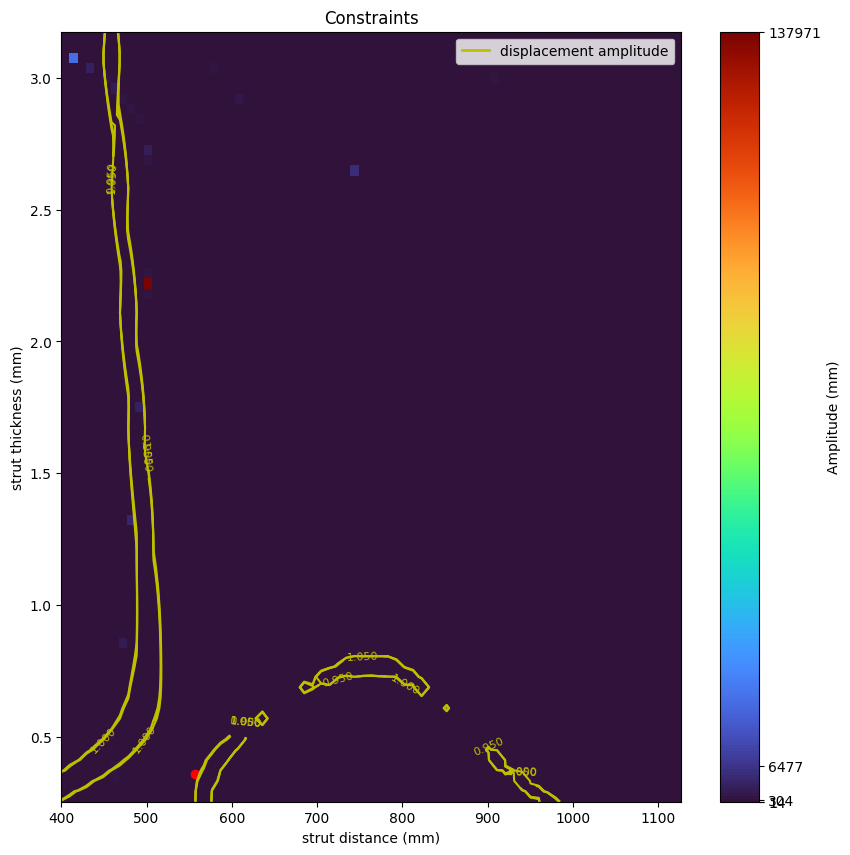

In [17]:

# zoomed out
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

Initial guess 1 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 25,
    "strut_diameter": 50.0,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31612437848973063
   strut_diameter: 50.0
   strut_thickness: 0.3602027837054039
   strut_distance: 509.98696996881597
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999970214
   stress: 0.955560709497491
   frequency: 0.26171190065852373
   energy: 0.326065371252493
   damage: 0.0
mass w/ payload: 0.8265042304244963 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16124378e-01 3.60202784e-01 5.09986970e+02]

Initial guess 2 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 1,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}


===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3022755041161241
   strut_diameter: 50.0
   strut_thickness: 0.3608985852993385
   strut_distance: 556.6928996805128
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999539
   stress: 0.9780731466461088
   frequency: 0.2914667465901592
   energy: 0.3260612237046038
   damage: 0.0
mass w/ payload: 0.8250114520506969 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275504e-01 3.60898585e-01 5.56692900e+02]

Inital Guess 3 tol=1e-18

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30227574532156787
   strut_diameter: 50.0
   strut_thickness: 0.3608980022929013
   strut_distance: 556.6928997650245
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.999999999999994
   stress: 0.9780730549779
   frequency: 0.29146623894235507
   energy: 0.32606122370460633
   damage: 0.0
mass w/ payload: 0.8250114520506582 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275745e-01 3.60898002e-01 5.56692900e+02]

Initial Guess 4 tol=1e-18

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31654251873360006
   strut_diameter: 50.0
   strut_thickness: 0.48657929350939877
   strut_distance: 412.17184660354866
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000013
   stress: 1.0000000000000078
   frequency: 1.0000000000001152
   energy: 0.3261353943704316
   damage: 0.0
mass w/ payload: 0.8461615400019418 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16542519e-01 4.86579294e-01 4.12171847e+02]

In [26]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc
uav_geo = opt.drone_geometry
uav_fea = fea.DroneFEA(uav_geo)
uav_fea.create_drone_nodes()
uav_fea.create_drone_beams()
# uav_fea.boundary_conditions()
uav_fea.solve_fea()
uav_fea.beam_system.solve_natural_frequencies()
np.set_printoptions(precision=3,suppress=True)
print(f"First Nf: {uav_fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {uav_fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")
print(f"Third Nf: {uav_fea.beam_system.natural_frequencies[2] * uc.rad_per_s_to_Hz} Hz")
print(f"Fourth Nf: {uav_fea.beam_system.natural_frequencies[3] * uc.rad_per_s_to_Hz} Hz")
print(f"Nf: {uav_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz} Hz")

First Nf: 0.0006284843555844116 Hz
Second Nf: 0.0006432995863308577 Hz
Third Nf: 0.0014286598014898687 Hz
Fourth Nf: 0.0023449964990000165 Hz
Nf: [    0.001     0.001     0.001     0.002     0.003     0.01     15.951
    16.795    16.795    18.555    18.555    22.671    23.426    23.426
    25.233    25.233    26.659    26.659    27.108    27.699    44.013
    44.05     44.05     44.15     44.15     44.26     44.26     44.327
    64.262    73.107    73.374    73.374    74.007    74.007    75.391
    75.391    76.61     76.61     84.537    84.539    84.539    84.543
    84.543    84.55     84.574    84.574   119.649   119.649   119.649
   119.649   119.649   119.65    119.652   119.652   134.306   134.306
   134.81    134.81    135.017   140.895   146.448   158.272   158.272
   158.37    158.37    158.376   166.331   166.331   166.373   166.373
   166.373   166.373   166.373   166.373   169.206   169.206   170.719
   170.719   314.73    314.73    314.736   314.736   314.739   374.678
  

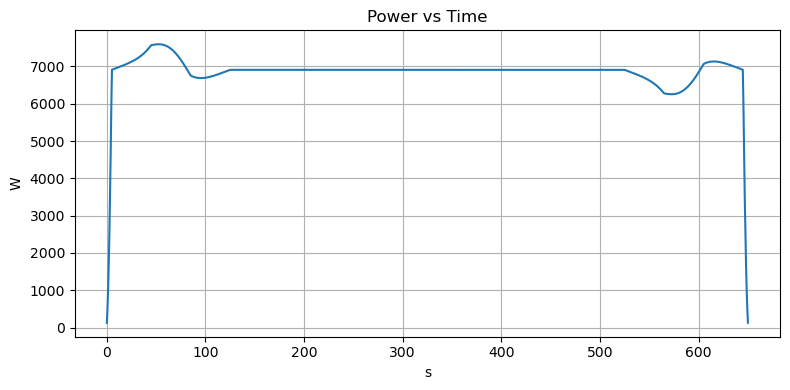

In [27]:
import matplotlib.pyplot as plt
import Scripts.unit_conversions as uc

drone_power = opt.drone_power_module
m1 = opt.mission_profile

power_list = drone_power.timesteps.copy()
thrust_list = drone_power.timesteps.copy()
osc_list = drone_power.timesteps.copy()
time_list = drone_power.timesteps.copy()
drone_mass = opt.drone_mass
surface_area = opt.drone_geometry.projected_surface_area
for i, t in enumerate(time_list):
    power_list[i] = drone_power.power_at_time(t)
    thrust_list[i] = opt.total_force_y(t, drone_mass, surface_area)
    osc_list[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)


print(opt.mission_profile)
# Power vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Power vs Time")
plt.plot(time_list, power_list / 1000)
plt.grid()
plt.ylabel("W")
plt.xlabel("s")
plt.tight_layout()
plt.show()

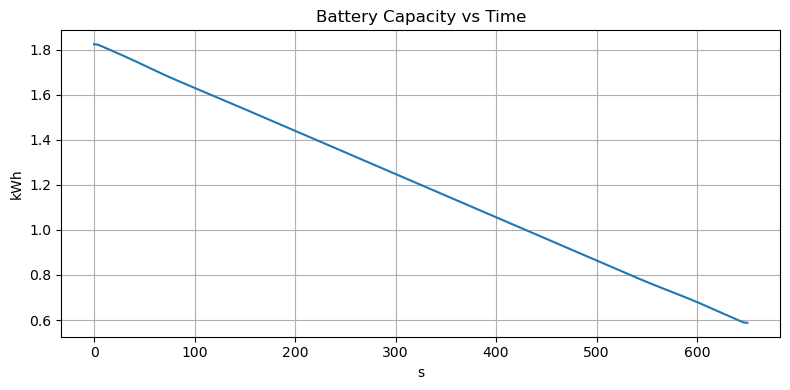

In [28]:

# Battery Capacity vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Battery Capacity vs Time")
plt.plot(drone_power.timesteps, drone_power.energy_remaining * uc.s_to_hrs * uc.mW_to_kW)
plt.grid()
plt.ylabel("kWh")
plt.xlabel("s")
plt.tight_layout()
plt.show()

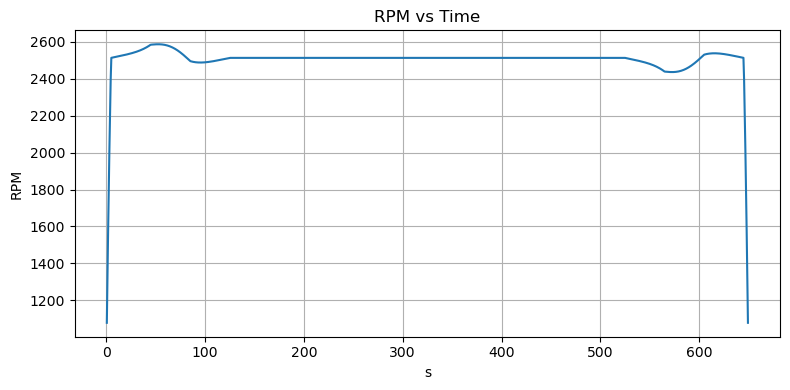

In [29]:

# Throttle vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("RPM vs Time")
plt.plot(drone_power.timesteps[1:-1], drone_power.rpm[1:-1])
plt.grid()
plt.ylabel("RPM")
plt.xlabel("s")
plt.tight_layout()
plt.show()


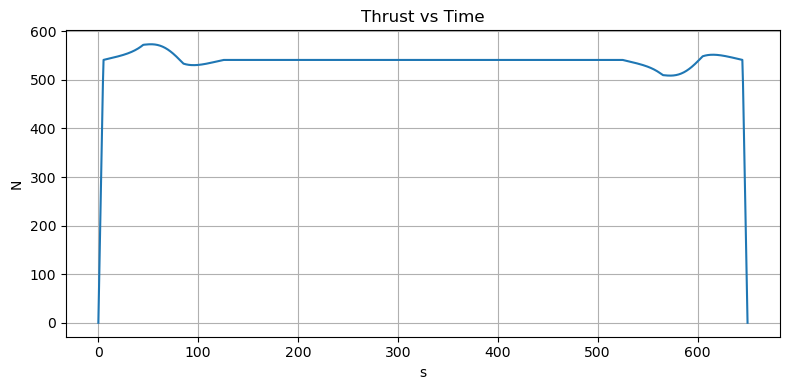

In [30]:
plt.figure(figsize=(8, 4))
plt.title("Thrust vs Time")
plt.plot(time_list, thrust_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

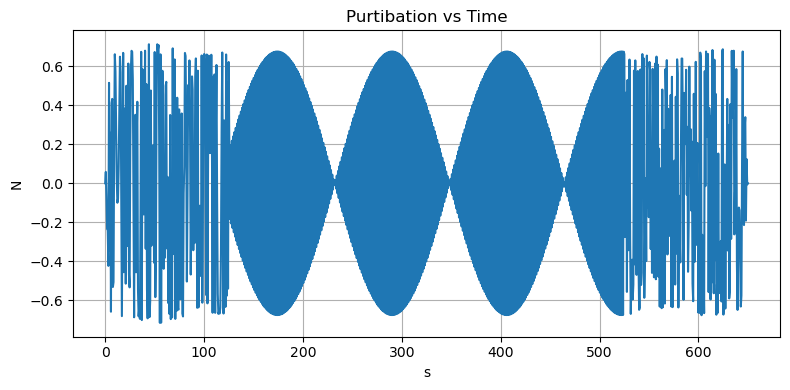

In [31]:
plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list, osc_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

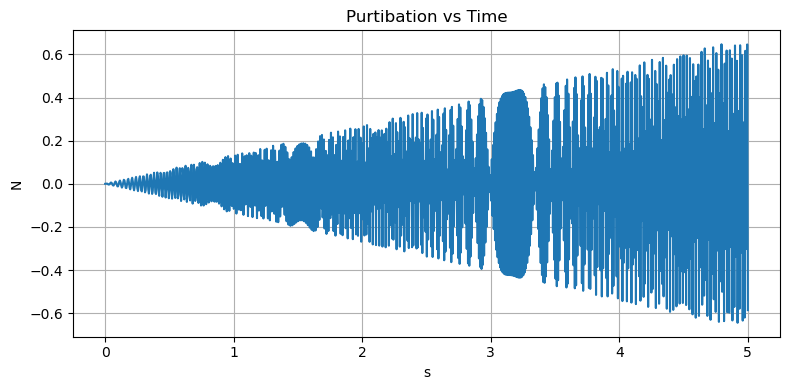

In [32]:

time_list_2 = np.linspace(0, 5, 1000)
osc_list_2 = np.zeros(len(time_list_2))
for i, t in enumerate(time_list_2):
    osc_list_2[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)

plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list_2, osc_list_2)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

In [33]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "arm_thickness", "strut_thickness", 30, design_variables, (0.2, 0.5), (0.2, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

KeyboardInterrupt: 

In [11]:

opt2 = Optimizer()
opt2.independent_properties_calc()
print(opt.mission_profile.duration)
opt2.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt2.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.3,
    "strut_distance": 475,
    "hub_radius": 250,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

res = opt2.run_opt()

x = np.array(res.x)
x_expanded = list(opt2.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt2.test_results(x)

dv_keys = list(opt2.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")

print("OPT_OUTPUT")
opt2.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640
Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30632490310676314
   strut_diameter: 50.0
   strut_thickness: 0.2540000000000001
   strut_distance: 263.9356150044375
   hub_radius: 250
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999993
   stress: 0.9350987280215738
   displacement amplitude: 1.0000000000000138
   energy: 0.8724376346301221
   damage: 0.0
mass w/ payload: 505.8390601718622 kg
OPT_OUTPUT
Initial guess opt actual:
[3.06324903e-01 2.54000000e-01 2.63935615e+02]


In [34]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc

## FEA Model Segment ##
fea_model_seg = opt.fea.beam_system

uav_fea_model_full = fea.DroneFEA(opt.drone_geometry)
uav_fea_model_full.create_drone_nodes()
uav_fea_model_full.create_drone_beams()
uav_fea_model_full.boundary_conditions()
uav_fea_model_full.solve_fea()

fea_model_full = uav_fea_model_full.beam_system


Full 50mm disp:
First 10 Natural Frequencies: [12.986 15.951 16.795 16.795 18.555 18.555 20.034 20.034 20.589 22.671
 23.426 23.426 25.233 25.233 26.991 26.991 27.699 44.013 44.05  44.05
 44.15  44.15  44.27  44.27  44.327 73.107 73.374 73.374 74.007 74.007] Hz
Segment 50mm disp:
First 10 Natural Frequencies: [   20.884    43.694    45.79     45.811    45.811    53.068    84.719
   119.693   148.765   166.373   315.769   900.972  1174.162  1309.738
  1309.842  2284.61   3817.981  5380.231  8001.889  9363.193 10743.614
 13228.599 15544.941 16130.848 19193.242 20259.926 20536.407 20547.524
 22815.119 23089.013] Hz
Prop Frequency Range: 81.20321259220303-86.22452532673637 Hz


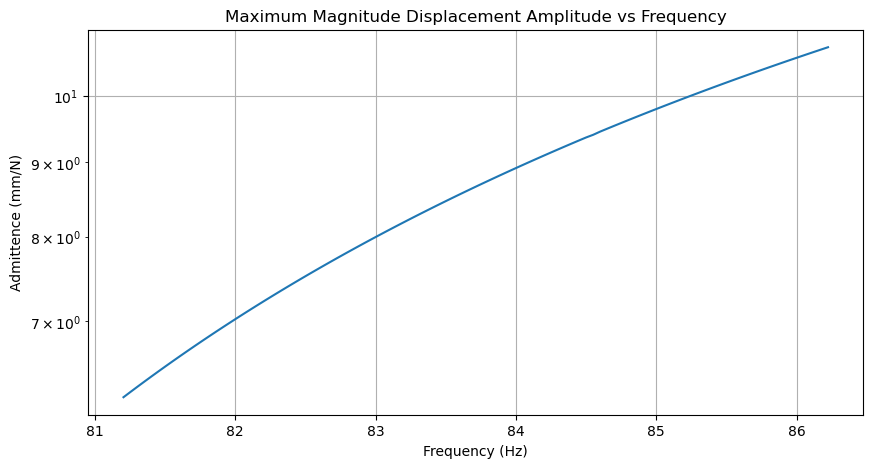

In [36]:
import matplotlib.pyplot as plt

## Freuency Analysis ##
fea_model_seg.solve_natural_frequencies()
fea_model_full.solve_natural_frequencies()

nat_fre_hz = fea_model_seg.natural_frequencies * uc.rad_per_s_to_Hz
full_nat_fre_hz = fea_model_full.natural_frequencies * uc.rad_per_s_to_Hz

print(f"Full 50mm disp:")
print(f"First 10 Natural Frequencies: {full_nat_fre_hz[:30]} Hz")

print("Segment 50mm disp:")
print(f"First 10 Natural Frequencies: {nat_fre_hz[:30]} Hz")


# Max Frequency #

drone_power = opt.drone_power_module
drone_power.freq_trans_calc()
max_freq = np.max(drone_power.frequency)
min_freq = np.min(drone_power.frequency[15:-15])
print(f"Prop Frequency Range: {min_freq * uc.rad_per_s_to_Hz}-{max_freq * uc.rad_per_s_to_Hz} Hz")

## Freuency Plotting ##
n_samples = 100
frequency_sample = np.linspace(min_freq, max_freq, n_samples)



max_amps = []
force = opt.parameters["gravity"] * (opt.parameters["payload"] / opt.parameters["blade_num"])
for freq in frequency_sample:
    test_freq_fea = fea_model_full
    test_freq_fea.init_dynamic_forces(freq)
    for i in range(7):
        node = f"outer_node_{i}"
        test_freq_fea.add_dynamic_harmonic_force(np.array([0, 0, 1, 0, 0, 0]), node)
    test_freq_fea.solve_dynamic_harmonic(0,0)
    max_amps.append(max(test_freq_fea.mag_displacements_amplitude))

plt.figure(figsize=(10, 5))
plt.plot(frequency_sample * uc.rad_per_s_to_Hz, max_amps)
plt.title("Maximum Magnitude Displacement Amplitude vs Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Admittence (mm/N)") #### Remeber ths ##
plt.grid(True)
plt.yscale('log')
plt.show()


In [26]:
## Energy Analysis ## 


drone_power = opt.drone_power_module

print(f"Total Energy Capacity: {drone_power.milliwatt_hour_capacity*10**-6} kWh")
print(f"Final Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} kWh")
print(f"% Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} %")
print(f"Mission Duration: {opt.mission_profile.duration} s")
print(f"Min Throttle: {np.min(drone_power.percent_throttle) * 100:.2f} %")
print(f"Average Throttle: {np.mean(drone_power.percent_throttle) * 100:.2f} %")
print(f"Peak Throttle: {np.max(drone_power.percent_throttle) * 100:.2f} %")


print(f"Min RPM: {np.min(drone_power.rpm) * 100:.2f} RPM")
print(f"Average RPM: {np.mean(drone_power.rpm) * 100:.2f} RPM")
print(f"Peak RPM: {np.max(drone_power.rpm) * 100:.2f} RPM")
print(f"Max RPM: 3068")



Total Energy Capacity: 1.8239999999999998 kWh
Final Energy Remaining: 0.5226889469200263 kWh
% Energy Remaining: 0.5226889469200263 %
Mission Duration: 640 s
Min Throttle: 0.79 %
Average Throttle: 45.00 %
Peak Throttle: 50.96 %
Min RPM: 80573.00 RPM
Average RPM: 253856.67 RPM
Peak RPM: 264226.16 RPM
Max RPM: 3068


I will summarize the analysis of the `drone_power` object by calculating and displaying its core attributes, including energy consumption and throttle performance over the mission duration.



In [85]:
# Displacement / Stress

fea_seg = opt.fea.beam_system

max_disp = print(f"max disp: {np.max(fea_seg.mag_displacements)}")
max_disp = print(f"max disp: {fea_seg.beams[fea_seg.select_element("outer_beam")].bending_stresses_0} Mpa")

max disp: 50.000000000000384
6
max disp: 75.58657942887487 Mpa


In [96]:
## MASS ##
dv = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": x_expanded[3],
    "strut_distance": x_expanded[4],
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
print(f"Initial Guess")
print(f"Frame mass: {opt.mass(opt.design_variables_initial_guess) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(opt.design_variables_initial_guess) * 10**-3}  kg*m^2")
print(f"Objective: {opt.objective(opt.design_variables_initial_guess)}")
print("Optimized")
print(f"Frame mass: {opt.mass(dv) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(dv) * 10**-3} kg*m^2")
print(f"Objective: {opt.objective(dv)}")

Initial Guess
Frame mass: 1.7057551016244064 kg
Frame mass moment of inertia: 0.34047109121624436  kg*m^2
Objective: 0.9384796481845028
Optimized
Frame mass: 1.053752071416452 kg
Frame mass moment of inertia: 0.14823664329358247 kg*m^2
Objective: 0.4850405167872752


In [100]:
drone_geometry = opt.drone_geometry
print(f"surface area projected: {drone_geometry.projected_surface_area} mm^2")

surface area projected: 843545.3826028954 mm^2


In [114]:
## Transient Results ##

print("Transient")
fea_seg = opt.fea.beam_system
for i in range(len(fea_seg.beams)):
    print(np.max(np.array([fea_seg.beams[i].bending_stresses_0_ts, fea_seg.beams[i].bending_stresses_1_ts])))

# 133 MPa
# Strength
print(f"Displacements: ")
for z in fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1]:
    print(f"{z}, ", end='')

print(f"\nMax Deflection: {np.max(fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1])}")

Transient
61.34911111304048
35.971926899155804
28.769411731577833
25.394016888397758
23.069976329079648
129.5976469005132
133.5505390451796
58.1253969103936
58.12539691039308
Displacements: 
0.0, 7.95198897982967, 15.719759071784013, 23.776485920402116, 31.71446932041046, 39.27071987226135, 48.05414102701513, 55.28924186058335, 61.56683798408395, 61.52804547669251, 60.94172077851061, 60.47783509776138, 61.43882733552373, 61.36503576396651, 60.73115349833751, 61.74854139740106, 60.84031221434113, 61.38621556845473, 61.84902912044872, 60.99702257156896, 60.832429865450834, 60.99777051945384, 61.04903165349139, 60.92928961166109, 61.51486551073131, 62.20087867981616, 61.14470457471524, 61.97394237578949, 62.46290771573594, 62.49441737879345, 62.25209602882383, 61.509837196519456, 62.08975623163047, 62.37370905485299, 61.73683543717816, 62.99759704249252, 63.0985006419326, 62.55524572425142, 63.38658419456533, 62.89041307019022, 63.658463925315566, 63.05856897175808, 63.656494591592825, 63

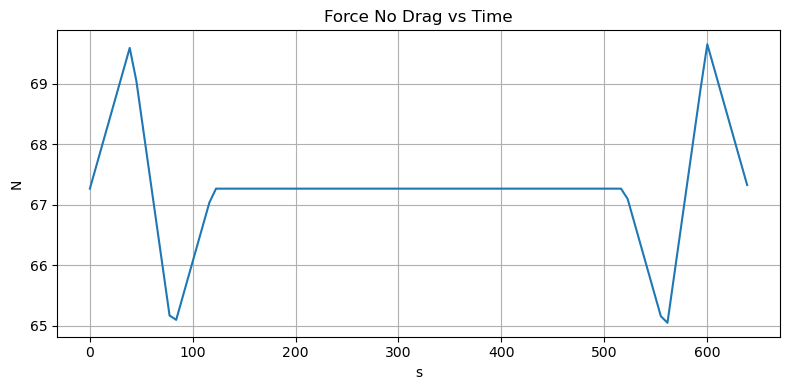

In [115]:
# force
plt.figure(figsize=(8, 4))
plt.title("Force No Drag vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
force = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    force[i] =  (a[1] + opt.parameters["gravity"]) * opt.drone_mass / opt.parameters["blade_num"]

plt.plot(t_range, force)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()



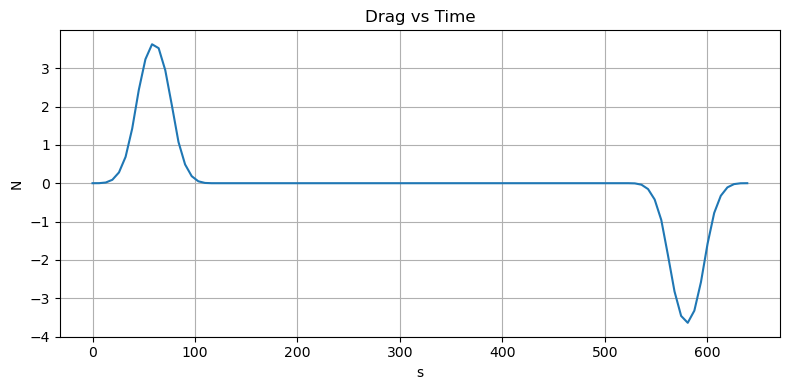

In [116]:




# Drag
plt.figure(figsize=(8, 4))
plt.title("Drag vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
drag = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    drag[i] = np.sign(v[1]) * (v[1] ** 2) * opt.drone_geometry.projected_surface_area * opt.parameters["air_density"] * opt.parameters["drag_coeff"] / 8

plt.plot(t_range, drag)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()
